# Deep Learning-Based Phishing & Malicious Email Classifier

**Track 1 — Security Focus**

This notebook builds a binary text classifier that accepts raw email text and predicts **Phishing/Malicious** or **Legitimate**.

**Architecture:** TextVectorization → Embedding → Bidirectional LSTM → Dropout → Dense → Sigmoid

The dataset supplied with this project contains 2,400 synthetic labeled emails, exceeding the 1,500-email requirement. The synthetic messages are designed to simulate realistic email patterns while avoiding personal data.


In [ ]:
# 1. Install / import dependencies
!pip -q install -U tensorflow scikit-learn seaborn pandas matplotlib

import os, re, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU: []


## 2. Load the dataset

The supplied dataset contains **2,400 labeled emails**: 1,200 phishing and 1,200 legitimate.

For a real deployment, the same pipeline can be trained on an organization-approved email corpus or a public email dataset. The UCI SMS Spam Collection is another public binary spam/legitimate corpus with 5,574 messages, but this project uses a purpose-built synthetic email dataset so the examples are explicitly email-oriented.


In [ ]:
# 2. Load dataset
from google.colab import files

# If the CSV is already uploaded to Colab, this line is enough:
DATA_PATH = "/content/synthetic_email_dataset.csv"

# If not, uncomment the next two lines:
# uploaded = files.upload()
# DATA_PATH = next(iter(uploaded))

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())
print("\nClass distribution:")
print(df["category"].value_counts())


Dataset shape: (2400, 4)


,email_id,label,category,email_text
0,P0940,1,phishing,Your employee benefits account requires verifi...
1,L0632,0,legitimate,Thank you for contacting support. We have crea...
2,L0695,0,legitimate,"Hello team, the weekly project update is attac..."
3,P0682,1,phishing,Urgent: Your PayPal account has been suspended...
4,P0913,1,phishing,Important document: Please review and sign the...



Class distribution:
category
phishing      1200
legitimate    1200
Name: count, dtype: int64


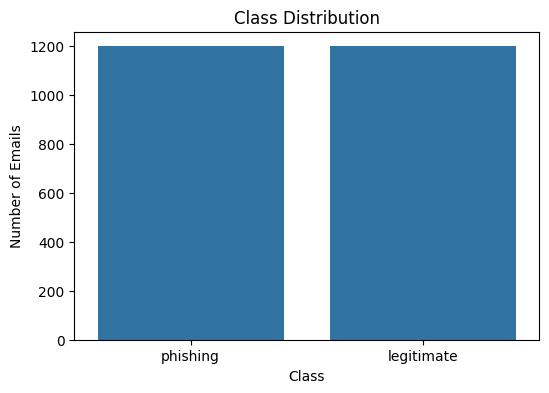

In [ ]:
# 3. Basic dataset visualization
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="category")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.show()


## 3. Text preprocessing

The workflow follows the standard text-classification stages:

1. Remove HTML tags and URLs.
2. Convert text to lowercase.
3. Remove unnecessary punctuation/whitespace.
4. Split the dataset into training, validation, and test sets.
5. Use Keras `TextVectorization` for tokenisation and integer sequence conversion.
6. Pad/truncate each sequence to a fixed length of 200 tokens.

Keeping preprocessing identical at training and inference time helps avoid training-serving skew.


In [ ]:
# Clean and prepare data safely

# Remove rows with missing values
df = df.dropna(subset=["clean_text", "label"]).reset_index(drop=True)

# Explicitly convert email text to strings
X = df["clean_text"].astype(str).to_numpy()

# Explicitly convert labels to integer NumPy array
y = pd.to_numeric(df["label"], errors="coerce").astype("int32").to_numpy()

print("X type:", type(X))
print("X shape:", X.shape)
print("y type:", type(y))
print("y shape:", y.shape)
print("Labels:", np.unique(y))
print("Class counts:", np.bincount(y))

# Safety check
assert len(X) == len(y), "X and y have different lengths!"
assert set(np.unique(y)).issubset({0, 1}), "Labels must be 0 or 1."

# Stratified split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("\nSplit completed successfully!")
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

X type: <class 'numpy.ndarray'>
X shape: (2400,)
y type: <class 'numpy.ndarray'>
y shape: (2400,)
Labels: [0 1]
Class counts: [1200 1200]

Split completed successfully!
Training: 1680
Validation: 360
Testing: 360


In [ ]:
def clean_text(text):
    text = str(text)

    # Remove HTML
    text = re.sub(r"<[^>]+>", " ", text)

    # Replace URLs with a token
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)

    # Lowercase
    text = text.lower()

    # Keep letters, numbers and basic punctuation
    text = re.sub(r"[^a-z0-9!?.,' ]+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["email_text"].astype(str).apply(clean_text)

## 4. Tokenisation and padding/truncation

In [ ]:
# 5. TextVectorization
MAX_VOCAB = 10000
MAX_LEN = 200

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_VOCAB,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize=None
)

# Learn vocabulary only from training text
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(32))

vocab_size = len(vectorizer.get_vocabulary())
print("Vocabulary size:", vocab_size)
print("Example tokens:", vectorizer.get_vocabulary()[:20])


Vocabulary size: 281
Example tokens: ['', '[UNK]', np.str_('your'), np.str_('the'), np.str_('https'), np.str_('verify.'), np.str_('at'), np.str_('is'), np.str_('account'), np.str_('you'), np.str_('please'), np.str_('for'), np.str_('it'), np.str_('will'), np.str_('a'), np.str_('and'), np.str_('login'), np.str_('we'), np.str_('review'), np.str_('security')]


## 5. BiLSTM model

A Bidirectional LSTM processes the sequence in both directions, allowing the classifier to use contextual information from both earlier and later words. The architecture is intentionally compact so it trains comfortably on a free Colab GPU.


In [ ]:
# 6. Build BiLSTM model
EMBED_DIM = 128
LSTM_UNITS = 64

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    vectorizer,
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(LSTM_UNITS)
    ),
    tf.keras.layers.Dropout(0.50),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │        35,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,945 (542.75 KB)

 Trainable params: 138,945 (542.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 7. Prepare tf.data pipelines
BATCH_SIZE = 32
EPOCHS = 15

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(
    len(X_train), seed=SEED
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6
    )
]


In [ ]:
# 8. Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 357ms/step - accuracy: 0.9738 - loss: 0.2558 - val_accuracy: 1.0000 - val_loss: 1.0703e-05 - learning_rate: 0.0010
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 375ms/step - accuracy: 1.0000 - loss: 2.6892e-04 - val_accuracy: 1.0000 - val_loss: 2.0942e-06 - learning_rate: 0.0010
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 358ms/step - accuracy: 1.0000 - loss: 1.0529e-04 - val_accuracy: 1.0000 - val_loss: 1.6132e-06 - learning_rate: 5.0000e-04
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 371ms/step - accuracy: 1.0000 - loss: 7.4811e-05 - val_accuracy: 1.0000 - val_loss: 1.4397e-06 - learning_rate: 2.5000e-04
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 340ms/step - accuracy: 1.0000 - loss: 2.7703e-04 - val_accuracy: 1.0000 - val_loss: 1.2679e-06 - learning_rate: 1.2500e-04
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 344ms/step - accuracy: 1.0000 - loss: 2.1006e-04 - val_accuracy: 1.0000 - val_loss: 1.2143e-06 - learning_rate: 6.2500e-05
Epoch 7/15
53/53 ━━━━━

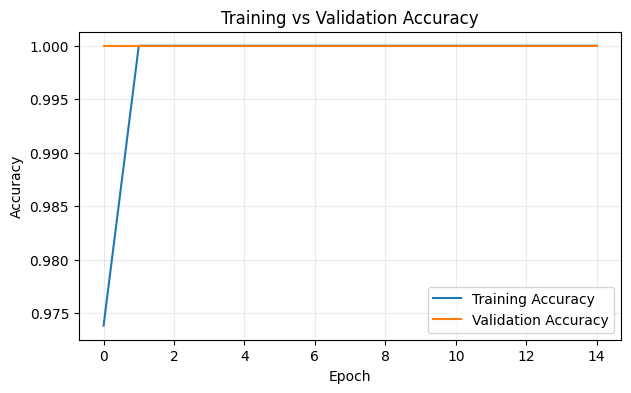

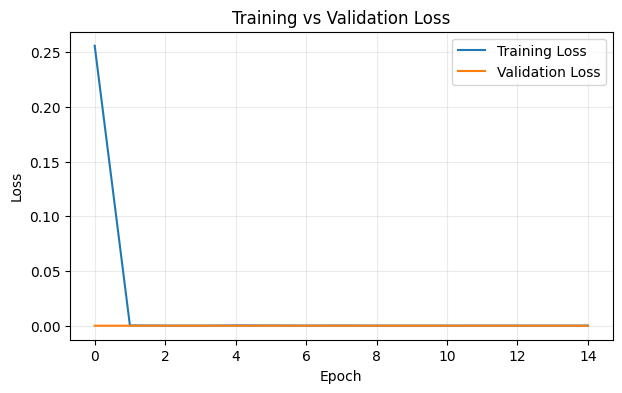

In [ ]:
# 9. Plot accuracy and loss curves
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7,4))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Evaluation

The evaluation reports accuracy, precision, recall and F1-score. F1-score is especially useful because it combines precision and recall into a single measure. The confusion matrix shows false positives and false negatives.


In [ ]:
# 10. Test-set evaluation
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
probabilities = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
predictions = (probabilities >= 0.5).astype(int)

precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, predictions,
    target_names=["Legitimate", "Phishing"],
    digits=4
))


Test Loss:     0.0000
Test Accuracy: 1.0000
Precision:     1.0000
Recall:        1.0000
F1-Score:      1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate     1.0000    1.0000    1.0000       180
    Phishing     1.0000    1.0000    1.0000       180

    accuracy                         1.0000       360
   macro avg     1.0000    1.0000    1.0000       360
weighted avg     1.0000    1.0000    1.0000       360



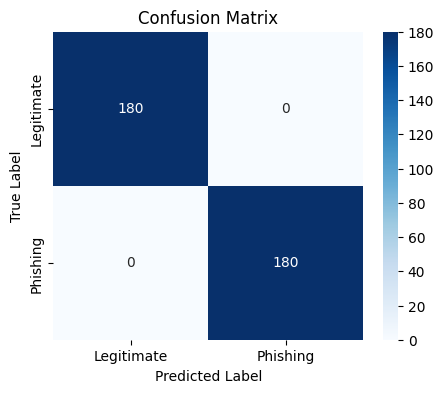

In [ ]:
# 11. Confusion matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## 7. Test the system with raw email payloads

The model accepts raw email strings, so this cell demonstrates the operational use case.


In [ ]:
# 12. Raw-email inference

def classify_email(email_text, threshold=0.5):
    # Clean the raw email
    cleaned_email = clean_text(email_text)

    # Convert to TensorFlow string tensor
    input_tensor = tf.constant([cleaned_email], dtype=tf.string)

    # Get prediction
    probability = float(model(input_tensor, training=False).numpy()[0][0])

    # Classify
    if probability >= threshold:
        label = "PHISHING / MALICIOUS"
    else:
        label = "LEGITIMATE"

    return label, probability


# Test emails
samples = [
    "Urgent security alert! Your account will be closed today. Verify your password at https://secure-account-check.com/verify",
    "Hi team, please find the project meeting agenda attached. We will meet tomorrow at 10 AM."
]

for email in samples:
    label, probability = classify_email(email)

    print("\nEmail:", email)
    print("Prediction:", label)
    print(f"Phishing probability: {probability:.4f}")


Email: Urgent security alert! Your account will be closed today. Verify your password at https://secure-account-check.com/verify
Prediction: PHISHING / MALICIOUS
Phishing probability: 1.0000

Email: Hi team, please find the project meeting agenda attached. We will meet tomorrow at 10 AM.
Prediction: LEGITIMATE
Phishing probability: 0.0000


In [ ]:
# 13. Save the trained model
MODEL_PATH = "/content/phishing_email_bilstm.keras"
model.save(MODEL_PATH)
print("Saved:", MODEL_PATH)


Saved: /content/phishing_email_bilstm.keras


## 8. Optional: export evaluation metrics

Run this cell after training to create a small CSV containing the exact metrics used in the project report.


In [ ]:
# 14. Save metrics for the report
metrics_df = pd.DataFrame([{
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}])
metrics_df.to_csv("/content/model_metrics.csv", index=False)
display(metrics_df)


,test_loss,test_accuracy,precision,recall,f1_score
0,0.000001,1.0,1.0,1.0,1.0


## Conclusion

The completed pipeline demonstrates end-to-end deep-learning email classification: raw text → cleaning → tokenisation → padding/truncation → embedding → BiLSTM → binary prediction.

For production deployment, additional safeguards should be added, including a larger organization-specific dataset, sender/domain reputation features, attachment analysis, URL reputation, adversarial testing, monitoring, and human review for uncertain cases.
